In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix


In [153]:
df = pd.read_csv('/content/drive/MyDrive/Transformed Data Set - Sheet1 (1).csv')
df.head()

,Favorite Color,Favorite Music Genre,Favorite Beverage,Favorite Soft Drink,Gender
0,Cool,Rock,Vodka,7UP/Sprite,F
1,Neutral,Hip hop,Vodka,Coca Cola/Pepsi,F
2,Warm,Rock,Wine,Coca Cola/Pepsi,F
3,Warm,Folk/Traditional,Whiskey,Fanta,F
4,Cool,Rock,Vodka,Coca Cola/Pepsi,F


In [154]:
df.shape

(66, 5)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Favorite Color        66 non-null     object
 1   Favorite Music Genre  66 non-null     object
 2   Favorite Beverage     66 non-null     object
 3   Favorite Soft Drink   66 non-null     object
 4   Gender                66 non-null     object
dtypes: object(5)
memory usage: 2.7+ KB


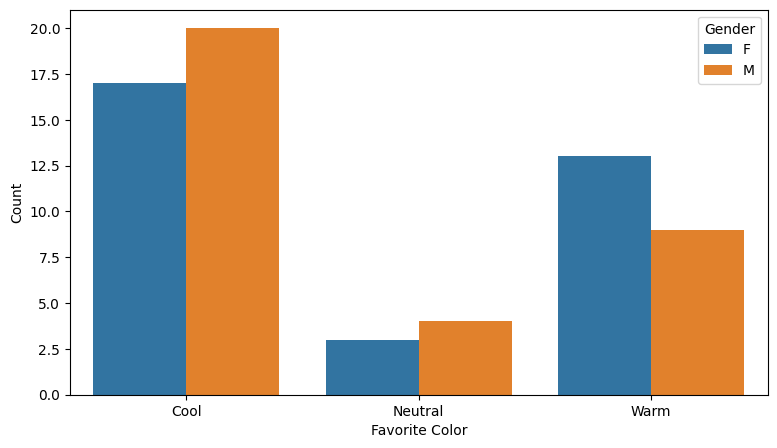

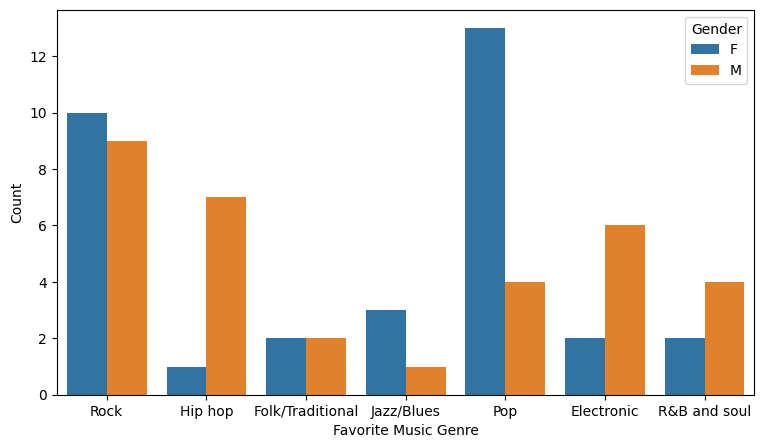

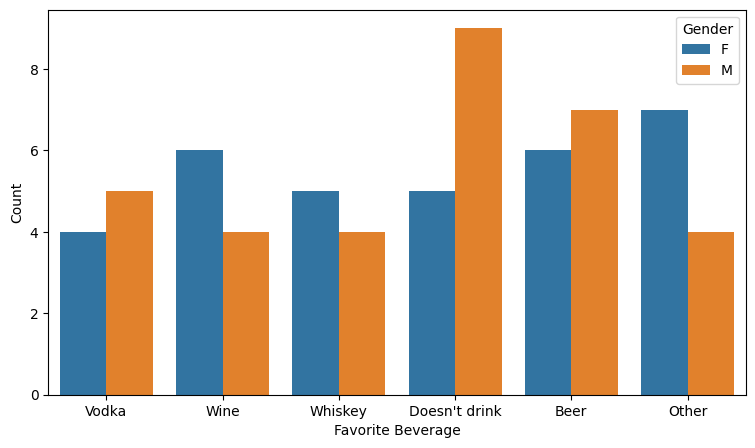

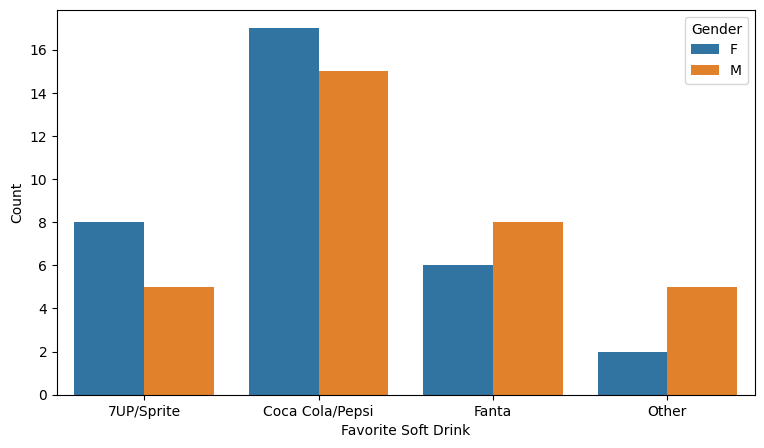

In [156]:
for col in ['Favorite Color', 'Favorite Music Genre',
            'Favorite Beverage', 'Favorite Soft Drink']:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=col, hue='Gender')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [157]:
for col in ['Favorite Color', 'Favorite Music Genre',
            'Favorite Beverage', 'Favorite Soft Drink', 'Gender']:
    print(col)
    print(df[col].value_counts())

Favorite Color
Favorite Color
Cool       37
Warm       22
Neutral     7
Name: count, dtype: int64
Favorite Music Genre
Favorite Music Genre
Rock                19
Pop                 17
Hip hop              8
Electronic           8
R&B and soul         6
Folk/Traditional     4
Jazz/Blues           4
Name: count, dtype: int64
Favorite Beverage
Favorite Beverage
Doesn't drink    14
Beer             13
Other            11
Wine             10
Vodka             9
Whiskey           9
Name: count, dtype: int64
Favorite Soft Drink
Favorite Soft Drink
Coca Cola/Pepsi    32
Fanta              14
7UP/Sprite         13
Other               7
Name: count, dtype: int64
Gender
Gender
F    33
M    33
Name: count, dtype: int64


In [158]:
x = pd.get_dummies(df.drop(columns = 'Gender'), drop_first=True)
y = df['Gender'].map({'F': 0, 'M': 1})

In [159]:
x.shape

(66, 16)

In [160]:
x.head()

,Favorite Color_Neutral,Favorite Color_Warm,Favorite Music Genre_Folk/Traditional,Favorite Music Genre_Hip hop,Favorite Music Genre_Jazz/Blues,Favorite Music Genre_Pop,Favorite Music Genre_R&B and soul,Favorite Music Genre_Rock,Favorite Beverage_Doesn't drink,Favorite Beverage_Other,Favorite Beverage_Vodka,Favorite Beverage_Whiskey,Favorite Beverage_Wine,Favorite Soft Drink_Coca Cola/Pepsi,Favorite Soft Drink_Fanta,Favorite Soft Drink_Other
0,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False
1,True,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False
2,False,True,False,False,False,False,False,True,False,False,False,False,True,True,False,False
3,False,True,True,False,False,False,False,False,False,False,False,True,False,False,True,False
4,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False


In [161]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42, stratify=y)

In [162]:
x_train.shape

(52, 16)

In [163]:
x_test.shape

(14, 16)

In [164]:
y_train.shape

(52,)

In [165]:
 y_test.shape

(14,)

In [166]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [167]:
pred = model.predict(x_test)

In [168]:
accuracy_score(y_test, pred)

0.7142857142857143

In [169]:
confusion_matrix(y_test,pred)
classification_report(y_test,pred)

'              precision    recall  f1-score   support\n\n           0       0.71      0.71      0.71         7\n           1       0.71      0.71      0.71         7\n\n    accuracy                           0.71        14\n   macro avg       0.71      0.71      0.71        14\nweighted avg       0.71      0.71      0.71        14\n'

In [170]:
("Training accuracy:", model.score(x_train, y_train))
("Testing accuracy:", model.score(x_test, y_test))

('Testing accuracy:', 0.7142857142857143)

In [171]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)



In [172]:
print('Train accuracy_score :-',accuracy_score(y_train,train_pred))
print('Train precision_score :-',precision_score(y_train,train_pred))
print('Train recall_score :-',recall_score(y_train,train_pred))
print('Train confusion_matrix :-\n',confusion_matrix(y_train,train_pred))

Train accuracy_score :- 0.7115384615384616
Train precision_score :- 0.7894736842105263
Train recall_score :- 0.5769230769230769
Train confusion_matrix :-
 [[22  4]
 [11 15]]


In [173]:
print('Test accuracy_score :-', accuracy_score(y_test, test_pred))
print('Test precision_score :-', precision_score(y_test, test_pred))
print('Test recall_score :-', recall_score(y_test, test_pred))
print('Test confusion_matrix :-\n', confusion_matrix(y_test, test_pred))

Test accuracy_score :- 0.7142857142857143
Test precision_score :- 0.7142857142857143
Test recall_score :- 0.7142857142857143
Test confusion_matrix :-
 [[5 2]
 [2 5]]


In [177]:
cv_scores = cross_val_score(model, x, y, cv=5, scoring='accuracy' )
print("Scores:",cv_scores)
print("Avrage_accuracy:",cv_scores.mean())

Scores: [0.42857143 0.76923077 0.76923077 0.46153846 0.38461538]
Avrage_accuracy: 0.5626373626373626
